### 2.1 理论计算题

1.  向量点积
    $$
    \mathbf{a} \cdot \mathbf{b} = a_1b_1 + a_2b_2 + a_3b_3 = 2 \times 1 + (-1) \times 4 + 3 \times (-2) = -8
    $$

2.  矩阵乘法
    $$
    A \times B =
    \begin{bmatrix}
    1 & 0 & 2 \\
    -1 & 3 & 1
    \end{bmatrix}
    \begin{bmatrix}
    2 & 1 \\
    0 & -1 \\
    3 & 2
    \end{bmatrix}
    =
    \begin{bmatrix}
    8 & 5 \\
    1 & -2
    \end{bmatrix}
    $$
    结果矩阵形状：$2 \times 2$

3.  向量a的Frobenius范数
    $$
    \|\mathbf{a}\|_F = \sqrt{\sum_{i=1}^{3} a_i^2} = \sqrt{2^2 + (-1)^2 + 3^2} = \sqrt{14} \approx 3.74
    $$

In [ ]:
#2.2 编程题
import numpy as np

# 1. 创建 3×4 标准正态分布随机矩阵 X
np.random.seed(42)  # 固定随机种子，保证结果可复现
X = np.random.randn(3, 4)
print('X =\n', X)

# 2. 创建 4×2 全1矩阵 Y
Y = np.ones((4, 2))
print('Y =\n', Y)


# 3. 计算矩阵乘法 Z = X × Y
Z = np.dot(X, Y)
print('Z = X @ Y =\n', Z)

# 4. 输出指定元素和行
print("\n4. Z 的第一行第二列元素：", Z[0, 1])
print("   Z 的第 2 行所有元素：", Z[1, :])  # Python 索引从 0 开始，第2行对应索引1

# 5. 计算 Z 的 Frobenius 范数
frobenius_norm = np.linalg.norm(Z)
print("\n5. Z 的 Frobenius 范数：", frobenius_norm)

X =
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]
Y =
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
Z = X @ Y =
 [[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

4. Z 的第一行第二列元素： 2.5291682463487657
   Z 的第 2 行所有元素： [1.87835721 1.87835721]

5. Z 的 Frobenius 范数： 4.616873319476864


### 3.1 理论计算题

设事件 $A$ 为“患病”，事件 $B$ 为“检测呈阳性”，根据题意：
$P(A)=0.1\%=0.001$，$P(\neg A)=1-P(A)=0.999$，
$P(B|A)=99\%=0.99$，$P(B|\neg A)=2\%=0.02$。

由贝叶斯公式：
$$
P(A|B) = \frac{P(B|A)P(A)}{P(B|A)P(A)+P(B|\neg A)P(\neg A)}
$$

代入计算：
$$
P(A|B) = \frac{0.99\times0.001}{0.99\times0.001+0.02\times0.999} \approx 0.0472
$$

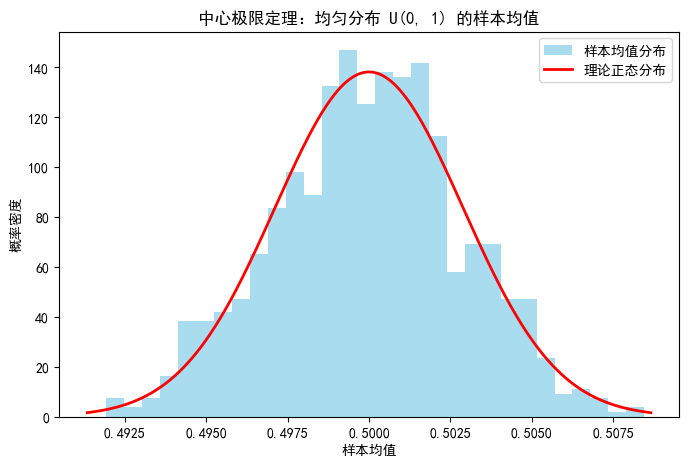

样本均值的实际方差: 8.2756370105107018e-06
理论方差: 8.3333333333333337e-06


In [11]:
#3.2 编程题用 Python 模拟中心极限定理：

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子，保证结果可复现
np.random.seed(42)

# 实验参数设置
n = 10000  # 每次生成的样本数量
m = 1000   # 重复实验的次数

# 存储每次实验得到的样本均值
sample_means = []

# 重复m次实验
for _ in range(m):
    # 生成n个服从U(0,1)均匀分布的随机数
    samples = np.random.uniform(low=0, high=1, size=n)
    # 计算这组样本的均值
    mean_val = np.mean(samples)
    # 将均值存入列表
    sample_means.append(mean_val)

# 转换为numpy数组，方便后续计算和绘图
sample_means = np.array(sample_means)

# 创建画布
plt.figure(figsize=(8, 5))

# 绘制样本均值的直方图
plt.hist(sample_means, bins=30, density=True, alpha=0.7, color='skyblue', label='样本均值分布')

# 计算理论正态分布的参数
# 均匀分布U(0,1)的均值为0.5，方差为1/12
# 根据中心极限定理，样本均值的分布近似为N(0.5, (1/12)/n)
mu = 0.5
var_theory = 1 / (12 * n)
std_theory = np.sqrt(var_theory)

# 生成理论正态分布的x轴和概率密度函数值
x = np.linspace(mu - 3 * std_theory, mu + 3 * std_theory, 1000)
pdf = norm.pdf(x, loc=mu, scale=std_theory)

# 绘制理论正态分布曲线（红色）
plt.plot(x, pdf, 'r-', linewidth=2, label='理论正态分布')

# 设置坐标轴标签和标题
plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title('中心极限定理：均匀分布 U(0, 1) 的样本均值')

plt.legend()
plt.grid(False)
plt.show()

# 计算样本均值的实际方差
actual_variance = np.var(sample_means, ddof=0)

print(f"样本均值的实际方差: {actual_variance:.16e}")
print(f"理论方差: {var_theory:.16e}")

### 4.1 理论计算题

1.  偏导数表达式
    $$
    \frac{\partial z}{\partial w_1} = 2(w_1x_1 + w_2x_2 - y)x_1
    $$
    $$
    \frac{\partial z}{\partial w_2} = 2(w_1x_1 + w_2x_2 - y)x_2
    $$

2.  梯度值计算（$x_1=2, x_2=1, y=3, w_1=0.5, w_2=1$）
    $$
    \frac{\partial z}{\partial w_1} = 2(0.5\times2 + 1\times1 - 3)\times2 = -4
    $$
    $$
    \frac{\partial z}{\partial w_2} = 2(0.5\times2 + 1\times1 - 3)\times1 = -2
    $$
    梯度：$\nabla z = (-4, -2)$

In [4]:
#4.2 编程题手动实现一个简单计算图的反向传播：
import torch

# 定义前向计算并计算前向结果
# 输入参数
x = 2
w1 = 1.5
w2 = 0.5

# 前向传播
a = x * w1
b = a + w2
L = b ** 2

print("前向传播结果：")
print(f"a = x * w1 = {x} * {w1} = {a}")
print(f"b = a + w2 = {a} + {w2} = {b}")
print(f"L = b^2 = {b}^2 = {L}")

# 手动计算梯度（链式法则）
# 链式法则：dL/dw1 = dL/db * db/da * da/dw1
#           dL/dw2 = dL/db * db/dw2
dL_db = 2 * b
db_da = 1
da_dw1 = x
db_dw2 = 1

dL_dw1 = dL_db * db_da * da_dw1
dL_dw2 = dL_db * db_dw2

print("\n手动计算梯度结果：")
print(f"dL/dw1 = {dL_dw1}")
print(f"dL/dw2 = {dL_dw2}")

# 使用PyTorch自动微分验证
# 定义需要求导的参数
w1_torch = torch.tensor(1.5, requires_grad=True)
w2_torch = torch.tensor(0.5, requires_grad=True)
x_torch = torch.tensor(2.0)

# 前向传播
a_torch = x_torch * w1_torch
b_torch = a_torch + w2_torch
L_torch = b_torch ** 2

# 反向传播
L_torch.backward()

print("\nPyTorch自动微分结果：")
print(f"dL/dw1 = {w1_torch.grad.item()}")
print(f"dL/dw2 = {w2_torch.grad.item()}")

# 验证结果是否一致
print(f"dL/dw1 是否一致：{abs(dL_dw1 - w1_torch.grad.item()) < 1e-6}")
print(f"dL/dw2 是否一致：{abs(dL_dw2 - w2_torch.grad.item()) < 1e-6}")

前向传播结果：
a = x * w1 = 2 * 1.5 = 3.0
b = a + w2 = 3.0 + 0.5 = 3.5
L = b^2 = 3.5^2 = 12.25

手动计算梯度结果：
dL/dw1 = 14.0
dL/dw2 = 7.0

PyTorch自动微分结果：
dL/dw1 = 14.0
dL/dw2 = 7.0
dL/dw1 是否一致：True
dL/dw2 是否一致：True


### 5.1 理论计算题

损失函数：
$$
L = \frac{1}{n}\sum_{i=1}^n (y_i - (wx_i + b))^2
$$

偏导数：
$$
\frac{\partial L}{\partial w} = -\frac{2}{n}\sum_{i=1}^n x_i(y_i - (wx_i + b))
$$
$$
\frac{\partial L}{\partial b} = -\frac{2}{n}\sum_{i=1}^n (y_i - (wx_i + b))
$$

In [5]:
#5.2 编程题从零实现 softmax 回归对手写数字（MNIST）进行分类：
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 1. 加载手写数字数据集（sklearn的digits数据集，相当于简化版MNIST）
data = load_digits()
X = data.data
y = data.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 数据预处理：图像展平 & 标签one-hot编码
# 图像已经是展平后的向量（8x8=64维），这里只做归一化
X_train = X_train / 16.0  # 像素值0-16，归一化到0-1
X_test = X_test / 16.0

# 标签one-hot编码
encoder = OneHotEncoder(sparse_output=False, categories='auto')
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

# 3. 实现softmax函数和交叉熵损失函数
def softmax(z):
    # 防止数值溢出，减去每一行的最大值
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    # 防止log(0)，加上一个极小值
    m = y_true.shape[0]
    log_likelihood = -np.log(y_pred[range(m), y_true.argmax(axis=1)] + 1e-10)
    loss = np.sum(log_likelihood) / m
    return loss

# 4. 初始化参数 & 训练配置
input_dim = X_train.shape[1]  # 输入维度64
output_dim = 10               # 分类数10
lr = 0.1                      # 学习率
epochs = 50                   # 训练轮数
batch_size = 32               # 批量大小

# 初始化权重和偏置
np.random.seed(42)
W = np.random.randn(input_dim, output_dim) * 0.01
b = np.zeros((1, output_dim))

# 训练过程
train_losses = []
for epoch in range(epochs):
    # 打乱训练数据
    permutation = np.random.permutation(X_train.shape[0])
    X_train_shuffled = X_train[permutation]
    y_train_shuffled = y_train_onehot[permutation]
    
    epoch_loss = 0
    # 小批量梯度下降
    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]
        
        # 前向传播
        z = np.dot(X_batch, W) + b
        y_pred = softmax(z)
        
        # 计算损失
        batch_loss = cross_entropy_loss(y_pred, y_batch)
        epoch_loss += batch_loss * len(X_batch)
        
        # 反向传播
        dz = y_pred - y_batch
        dW = np.dot(X_batch.T, dz) / len(X_batch)
        db = np.sum(dz, axis=0, keepdims=True) / len(X_batch)
        
        # 更新参数
        W -= lr * dW
        b -= lr * db
    
    epoch_loss /= X_train.shape[0]
    train_losses.append(epoch_loss)
    
    # 每10个epoch打印一次损失
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, 训练损失: {epoch_loss:.4f}")

# 5. 计算测试集准确率
def predict(X, W, b):
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    return np.argmax(y_pred, axis=1)

y_pred_test = predict(X_test, W, b)
accuracy = np.mean(y_pred_test == y_test)
print(f"\n测试集准确率: {accuracy:.4f}")

Epoch 10/50, 训练损失: 0.4571
Epoch 20/50, 训练损失: 0.3003
Epoch 30/50, 训练损失: 0.2405
Epoch 40/50, 训练损失: 0.2079
Epoch 50/50, 训练损失: 0.1858

测试集准确率: 0.9583


### 6.1 理论计算题

1.  似然函数
    $$
    L(\mu,\sigma^2) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x_i-\mu)^2}{2\sigma^2}}
    $$

2.  $\mu$ 的最大似然估计
    对数似然：
    $$
    \ell(\mu,\sigma^2) = -\frac{n}{2}\ln(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n(x_i-\mu)^2
    $$
    对 $\mu$ 求偏导并令其为 0：
    $$
    \frac{\partial \ell}{\partial \mu} = \frac{1}{\sigma^2}\sum_{i=1}^n(x_i-\mu) = 0
    $$
    解得：
    $$
    \hat{\mu} = \frac{1}{n}\sum_{i=1}^n x_i
    $$

3.  $\sigma^2$ 的最大似然估计
    对 $\sigma^2$ 求偏导并令其为 0：
    $$
    \frac{\partial \ell}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2\sigma^4}\sum_{i=1}^n(x_i-\hat{\mu})^2 = 0
    $$
    解得：
    $$
    \hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n(x_i-\hat{\mu})^2
    $$

Epoch 100/1000, Loss: 0.0324
Epoch 200/1000, Loss: 0.0208
Epoch 300/1000, Loss: 0.0163
Epoch 400/1000, Loss: 0.0139
Epoch 500/1000, Loss: 0.0122
Epoch 600/1000, Loss: 0.0111
Epoch 700/1000, Loss: 0.0102
Epoch 800/1000, Loss: 0.0095
Epoch 900/1000, Loss: 0.0090
Epoch 1000/1000, Loss: 0.0085

测试集分类准确率: 1.0000


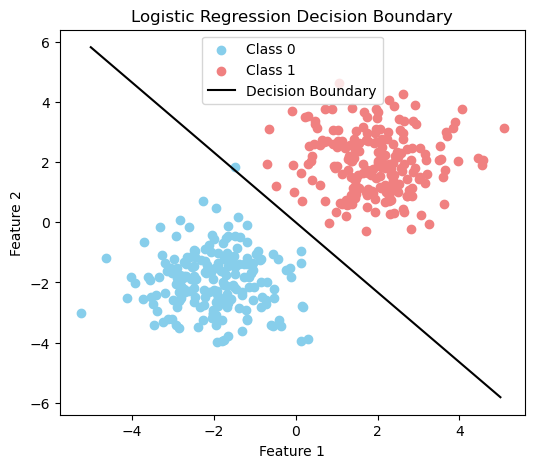

In [ ]:
#6.2 编程题实现二分类逻辑回归模型（不使用深度学习框架的高阶 API）：

import numpy as np
import matplotlib.pyplot as plt

# 1. 生成两类线性可分的数据
np.random.seed(42)

# 类别0：均值(-2, -2)
class0 = np.random.randn(200, 2) + np.array([-2, -2])
# 类别1：均值(2, 2)
class1 = np.random.randn(200, 2) + np.array([2, 2])

# 合并数据
X = np.vstack([class0, class1])
y = np.hstack([np.zeros(200), np.ones(200)]).reshape(-1, 1)

# 生成测试集（100个样本）
test_class0 = np.random.randn(50, 2) + np.array([-2, -2])
test_class1 = np.random.randn(50, 2) + np.array([2, 2])
X_test = np.vstack([test_class0, test_class1])
y_test = np.hstack([np.zeros(50), np.ones(50)]).reshape(-1, 1)


# 2. 定义 sigmoid 函数和二元交叉熵损失
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    m = y_true.shape[0]
    return -1/m * np.sum(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))


# 3. 梯度下降法学习参数 w, b
# 初始化参数
w = np.zeros((2, 1))
b = 0
lr = 0.1
epochs = 1000
m = X.shape[0]

for epoch in range(epochs):
    # 前向传播
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    
    # 计算损失
    loss = binary_cross_entropy(y_pred, y)
    
    # 反向传播
    dw = 1/m * np.dot(X.T, (y_pred - y))
    db = 1/m * np.sum(y_pred - y)
    
    # 更新参数
    w -= lr * dw
    b -= lr * db
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")


# 4. 绘制决策边界 & 计算测试集准确率
def predict(X, w, b):
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    return (y_pred > 0.5).astype(int)

# 计算测试集准确率
y_pred_test = predict(X_test, w, b)
acc = np.mean(y_pred_test == y_test)
print(f"\n测试集分类准确率: {acc:.4f}")

# 绘制数据点和决策边界
plt.figure(figsize=(6, 5))
plt.scatter(class0[:, 0], class0[:, 1], c='skyblue', label='Class 0')
plt.scatter(class1[:, 0], class1[:, 1], c='lightcoral', label='Class 1')

# 决策边界：w1*x1 + w2*x2 + b = 0 => x2 = (-w1*x1 - b)/w2
x1 = np.linspace(-5, 5, 100)
x2 = (-w[0, 0] * x1 - b) / w[1, 0]
plt.plot(x1, x2, 'k-', label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Logistic Regression Decision Boundary')
plt.show()
